# Task 5 Individual Report

My assigned train/test split: 50 : 50

Approach: Task 5 does not re-tune the models. It takes the hyperparameters already
selected in Tasks 2, 3 and 4 (the group's best models), re-fits each one on my 50:50
training partition, and evaluates on my 50:50 test partition. Only the split changes
between the three group members, so the results can be compared like-for-like for the
"consistency across splits" discussion in Q5.3.

Best models carried over from the group tasks:

| Task | Best model | Fixed settings |
|---|---|---|
| 2 | Tuned decision tree | `criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=20` |
| 3 | Tuned logistic regression | `StandardScaler` + `C = 1` (all 62 features) |
| 4 | Tuned neural network | `StandardScaler` + `hidden_layer_sizes=(20,), alpha=0.01, activation='relu', solver='adam', max_iter=1000` (all 62 features) |



In [ ]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, classification_report)

TEST_SIZE = 0.50          
RANDOM_STATE = 42        
LR_USE_REDUCED = False    

## Data preparation (same as Task 1)

In [2]:
df = pd.read_csv('dataset_ifn580_262_v1.csv')

df = df.drop(columns=['car'])
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
for col in ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['age'] = df['age'].map({'below21':0,'21':1,'26':2,'31':3,'36':4,'41':5,'46':6,'50plus':7})
df['time'] = df['time'].map({'7AM':0,'10AM':1,'2PM':2,'6PM':3,'10PM':4})
df['income'] = df['income'].map({'Less than $12500':0,'$12500 - $24999':1,'$25000 - $37499':2,
                                 '$37500 - $49999':3,'$50000 - $62499':4,'$62500 - $74999':5,
                                 '$75000 - $87499':6,'$87500 - $99999':7,'$100000 or More':8})
df['education'] = df['education'].map({'Some High School':0,'High School Graduate':1,
                                      'Some college - no degree':2,'Associates degree':3,
                                      'Bachelors degree':4,
                                      'Graduate degree (Masters or Doctorate)':5})
freq_map = {'never':0,'less1':1,'1~3':2,'4~8':3,'gt8':4}
for col in ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']:
    df[col] = df[col].map(freq_map)
df['expiration'] = df['expiration'].map({'2h':0,'1d':1})
df['gender'] = df['gender'].map({'Female':0,'Male':1})

df = pd.concat([df, pd.get_dummies(df['destination'], prefix='destination', dtype=int)], axis=1)
df = df.drop(columns=['destination'])
nominal_columns = ['passanger','weather','coupon','maritalStatus','occupation']
df = pd.concat([df, pd.get_dummies(df[nominal_columns], prefix=nominal_columns, dtype=int)], axis=1)
df = df.drop(columns=nominal_columns)
df = df.drop(columns=['direction_opp'])

X = df.drop(columns=['is_accepted'])
y = df['is_accepted']
feature_names = X.columns
print("features:", X.shape[1], "| rows:", X.shape[0])

features: 62 | rows: 12684


## My 50:50 train / test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"split {int((1-TEST_SIZE)*100)}:{int(TEST_SIZE*100)}")
print("train:", X_train.shape, " test:", X_test.shape)
print("test-set class balance:", np.round(np.bincount(y_test) / len(y_test), 3))


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train, y_train)
X_test_s = scaler.transform(X_test)

split 50:50
train: (6342, 62)  test: (6342, 62)
test-set class balance: [0.434 0.566]


## Re-fit the best model from each of Tasks 2, 3 and 4 on my split

In [ ]:
results = {}      
roc_data = {}     

def evaluate(name, model, Xtr, ytr, Xte, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_time = time.time() - t0
    proba = model.predict_proba(Xte)[:, 1]
    pred = model.predict(Xte)
    fpr, tpr, _ = roc_curve(yte, proba)
    auc = roc_auc_score(yte, proba)
    results[name] = {
        "train_acc": accuracy_score(ytr, model.predict(Xtr)),
        "test_acc":  accuracy_score(yte, pred),
        "precision": precision_score(yte, pred),
        "recall":    recall_score(yte, pred),
        "f1":        f1_score(yte, pred),
        "roc_auc":   auc,
        "fit_time_s": round(fit_time, 3),
    }
    roc_data[name] = (fpr, tpr, auc)
    print(f"\n=== {name} ===")
    print(classification_report(yte, pred))
    return model

# Task 2 best: tuned decision tree (unscaled)
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10,
                            min_samples_leaf=1, min_samples_split=20,
                            random_state=RANDOM_STATE)
dt = evaluate("Decision Tree (Task 2 best)", dt, X_train, y_train, X_test, y_test)

# Task 3 best: tuned logistic regression (scaled) 
if LR_USE_REDUCED:
    sel = SelectFromModel(dt, prefit=True, threshold='mean')
    Xtr_lr, Xte_lr = sel.transform(X_train_s), sel.transform(X_test_s)
    lr_name = "Logistic Regression; reduced (Task 3 best)"
else:
    Xtr_lr, Xte_lr = X_train_s, X_test_s
    lr_name = "Logistic Regression (Task 3 best)"
lr = LogisticRegression(C=1, random_state=RANDOM_STATE, max_iter=1000)
lr = evaluate(lr_name, lr, Xtr_lr, y_train, Xte_lr, y_test)

# Task 4 best: tuned neural network (scaled, all features)
nn = MLPClassifier(hidden_layer_sizes=(20,), alpha=0.01, activation='relu',
                   solver='adam', max_iter=1000, random_state=RANDOM_STATE)
nn = evaluate("Neural Network (Task 4 best)", nn, X_train_s, y_train, X_test_s, y_test)


=== Decision Tree (Task 2 best) ===
              precision    recall  f1-score   support

           0       0.62      0.58      0.60      2754
           1       0.69      0.73      0.71      3588

    accuracy                           0.67      6342
   macro avg       0.66      0.66      0.66      6342
weighted avg       0.66      0.67      0.66      6342


=== Logistic Regression (Task 3 best) ===
              precision    recall  f1-score   support

           0       0.64      0.57      0.60      2754
           1       0.70      0.75      0.72      3588

    accuracy                           0.67      6342
   macro avg       0.67      0.66      0.66      6342
weighted avg       0.67      0.67      0.67      6342




=== Neural Network (Task 4 best) ===
              precision    recall  f1-score   support

           0       0.66      0.61      0.64      2754
           1       0.72      0.76      0.74      3588

    accuracy                           0.70      6342
   macro avg       0.69      0.69      0.69      6342
weighted avg       0.69      0.70      0.69      6342



## Summary table of key performance metrics (my 50:50 test set)

In [5]:
summary = pd.DataFrame(results).T
summary = summary[["train_acc", "test_acc", "precision", "recall", "f1", "roc_auc", "fit_time_s"]]
summary["train_test_gap"] = summary["train_acc"] - summary["test_acc"]
summary = summary.round(4)
summary

,train_acc,test_acc,precision,recall,f1,roc_auc,fit_time_s,train_test_gap
Decision Tree (Task 2 best),0.7832,0.6654,0.6934,0.7324,0.7124,0.7142,0.023,0.1178
Logistic Regression (Task 3 best),0.6949,0.6736,0.6961,0.7508,0.7224,0.7201,0.008,0.0213
Neural Network (Task 4 best),0.8329,0.6957,0.7190,0.7586,0.7383,0.7524,1.962,0.1372


## ROC curves; the three best models on my 50:50 test set

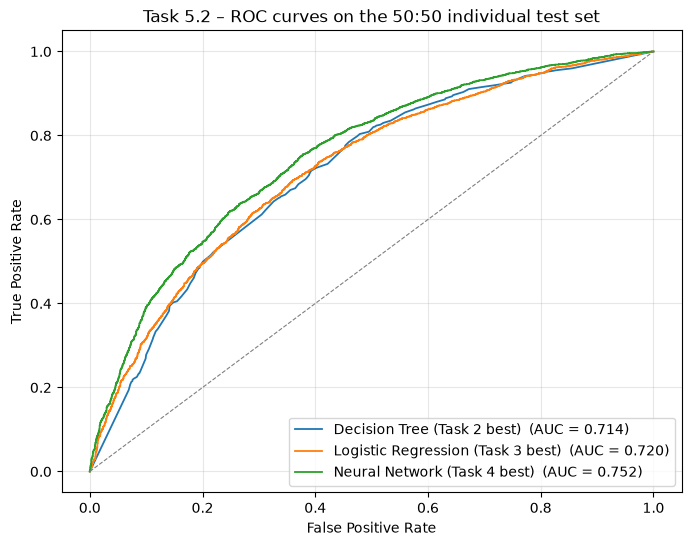

In [6]:
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, lw=1.3, label=f"{name}  (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Task 5.2 – ROC curves on the 50:50 individual test set")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()



## 5.1 Individual contribution

I did Task 4 (Neural Networks) and my part of Task 5.

For Task 4 I built and tuned the neural network models. I standardised all 62 features with StandardScaler, fitting it on the training data only, then used GridSearchCV to search over the hidden-layer size and the alpha regularisation term. I checked whether the training runs converged, built a second network on the smaller feature set that the Task 2 decision tree selected, and compared the two models with ROC curves.

For Task 5 I re-fitted the best model from each of Tasks 2, 3 and 4 on my own split, produced the metrics table and ROC plot, and wrote the analysis below.

My estimated contribution is 33.33%, which matches the figure in the Team Agreement.

Split: 50:50 train/test, random_state = 42. That gives 6,342 training rows and 6,342 test rows, with the test set 43.4% decline and 56.6% accept.

## 5.2 Strengths and limitations of the models

Decision tree (entropy, depth 10). Easy to read, quick to build. It trained in 0.02 seconds and produces if/else rules a non-technical reader can follow. Its weakness is over-fitting: 0.783 accuracy on the training data against 0.665 on the test data, a gap of 0.118. It also had the lowest AUC of the three (0.714), making it the weakest at ranking customers by likelihood of acceptance. It captures the general pattern but not the detail.

Logistic regression (C = 1, standardised inputs). The most stable of the three. Training and test accuracy were almost identical (gap of 0.021), so its test score is the most reliable, and every coefficient carries a sign showing whether a feature raises or lowers the chance of acceptance. Its AUC of 0.720 is roughly the same as the neural network's. The limitation is that it only fits linear relationships, so it cannot pick up interactions such as a takeaway coupon working only when the expiry window is long.

Neural network (one hidden layer, 20 neurons, alpha 0.01). Best at separating accepters from decliners: the highest AUC (0.752) and the best precision, recall and F1 (0.719, 0.759, 0.738). It also over-fit the most, at a train–test gap of 0.137. Training took about 2 seconds against a hundredth of a second for the other two, and it gives no explanation for its predictions, so you cannot tell a stakeholder why a given customer was flagged.

## 5.3 Recommended best-performing model

The neural network is the best-performing model on my split, though logistic regression runs it close and is easier to interpret.

Architecture: One hidden layer of 20 neurons, ReLU activation, Adam optimiser, L2 penalty alpha = 0.01. That single small layer is what lifts its AUC above the two linear-ish models; larger hidden layers scored no better in cross-validation and started to over-fit.

Features: All 62 standardised features. Cutting down to the 16 the decision tree rated highly (Task 4.3) left the AUC near 0.75 either way, so there was no reason to drop the rest.

Consistency across splits: On my 50:50 split the order is NN 0.752, LR 0.720, DT 0.714. 

Over-fitting: The 0.137 train–test gap is the main concern, and the widest of the three models. Early stopping or a larger alpha would bring it down before the model is used in practice.

Interpretability: The network gives no reason for any single prediction. That matters here, because the aim of the exercise is to explain what drives coupon acceptance, and only logistic regression's signed coefficients do that.

Computational cost: Training took 1.96 s against about 0.01 s for the other two, plus a GridSearchCV over 20 configurations. Trivial at this scale, but it would not stay trivial if the model had to retrain often on fresh data.

Hyperparameter sensitivity: Moderate. Changing the hidden-layer size or alpha shifted cross-validation accuracy by only a point or two, and training stopped on its own at 450 of 1000 iterations. The decision tree was far more fragile: an unbounded tree reached ~100% training accuracy and over-fit badly. Logistic regression barely moved between C = 0.01 and C = 1.



## 5.4 Strategies to improve the best-performing model

Cyclic encoding of time: Right now time is an ordinal 0–4 code, so the model has no way of knowing that 10PM sits next to 7AM. Encoding it as the sin and cos of the hour gives a continuous daily cycle and should let the models pick up time-of-day effects more cleanly.

Interaction features: The logistic regression can only add features up, not combine them. Building a few interaction terms by hand, such as coupon type with expiration and destination with passenger, would give it access to combined effects like a takeaway coupon paired with a one-day window. The neural network can already learn these in its hidden layer, but handing them over directly makes that job easier.

Better encoding of high-cardinality categoricals: occupation turns into 25 mostly-empty dummy columns. Swapping that for target or frequency encoding collapses it to one or two columns and removes a lot of noise, which should help the neural network's over-fitting gap.

Regularisation and architecture search for the neural network: Turn on early_stopping, search a wider range of alpha, and try a second hidden layer. The aim is to shrink the 0.137 train–test gap while keeping the AUC lead.